In [50]:
import pandas as pd
import numpy as np
from math import log10, log, exp
import re
import matplotlib.pyplot as plt
from random import randint
from sklearn.model_selection import train_test_split

读取CSV并筛选出β-衰变

In [51]:
df = pd.read_csv("nndc_nudat_data_export.csv", encoding="utf-8")
mask_halflife = df["halflife"].notna()
mask_beta_filter = df["decayMode"].isin(["β⁻"])
df_beta_filtered = df[mask_halflife & mask_beta_filter]
df_beta_filtered.to_csv("filtered_beta_decays.csv",index=False,encoding="utf-8-sig")

halflife_values = df_beta_filtered["halflife"].to_numpy()
halflife_units = df_beta_filtered["halflifeUnit"].to_numpy()
halflife_uncertainty = df_beta_filtered["halflifeUncertainty"].to_numpy()
halflife_log_sec = []
halflife_log_secUncertainty = []
betaMinusQ = df_beta_filtered["betaMinus"].to_numpy()
betaMinusQUncertainty = df_beta_filtered["betaMinusUncertainty"].to_numpy()
Np = df_beta_filtered["z"].to_numpy()
Nn = df_beta_filtered["n"].to_numpy()
Na = Nn+Np
NNuc = len(halflife_values)
for i in range(NNuc):
    betaMinusQUncertainty[i] = abs(betaMinusQUncertainty[i])/(betaMinusQ[i]*log(10))
    betaMinusQ[i] = log10(betaMinusQ[i])
    val = float(re.sub(r'[^\d\.\-Ee]', '', str(halflife_values[i])))
    if '-' in str(halflife_uncertainty[i]):
        parts = halflife_uncertainty[i].split('-')
        val_unc = (float(parts[0]) + float(parts[1])) / 2
    elif pd.isna(halflife_uncertainty[i]) or str(halflife_uncertainty[i]).strip() == '' or '>' in str(halflife_uncertainty[i]).lower():
        val_unc = 0.0
    else:
        val_unc = float(re.sub(r'[^\d\.\-Ee]', '', str(halflife_uncertainty[i])))
    match halflife_units[i]:
        case 'ms':
            halflife_log_sec.append(log10(val/1000))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 's':
            halflife_log_sec.append(log10(val))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'm':
            halflife_log_sec.append(log10(val*60))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'h':
            halflife_log_sec.append(log10(val*3600))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'd':
            halflife_log_sec.append(log10(val*3600*24))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'y':
            halflife_log_sec.append(log10(val*3600*24*365.25))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))



delta = np.zeros_like(Np, dtype=int)
delta[(Np % 2 == 1) & (Nn % 2 == 1)] = 1
delta[(Np % 2 == 0) & (Nn % 2 == 0)] = -1

I=(Nn-Np)/(Nn+Np)

J_value = np.zeros(NNuc, dtype=float)
parity_sign = np.zeros(NNuc, dtype=int)      # +1, -1, 0
uncertain_flag = np.zeros(NNuc, dtype=int)   # 0:确定, 1:括号不确定, 2:完全缺失/异常
spin_parity_raw = df_beta_filtered["spinAndParity"].astype(str).to_numpy()
for i, sp in enumerate(spin_parity_raw):
    sp = sp.strip()
    # 处理完全缺失或明显异常的值（如 "-3", "-5", "-1", 空字符串, "nan"）
    if sp == "" or sp == "nan" or sp in ["-3", "-5", "-1"] or re.match(r'^-?\d+$', sp):
        uncertain_flag[i] = 2
        # 临时填0，后续统一用物理规则填补
        J_value[i] = 0.0
        parity_sign[i] = 0
        continue

    # 检测不确定性标志：包含括号或分号（表示多种可能）则视为不确定
    if '(' in sp or ')' in sp or ';' in sp:
        uncertain_flag[i] = 1
    else:
        uncertain_flag[i] = 0

    # 移除括号和空格，便于提取宇称和自旋
    sp_clean = re.sub(r'[\(\)\s]', '', sp)
    # 处理分号分隔的多个可能值，取第一个
    if ';' in sp_clean:
        sp_clean = sp_clean.split(';')[0]

    # 提取宇称符号（+ 或 -）
    if '+' in sp_clean:
        parity_sign[i] = 1
        sp_clean = sp_clean.replace('+', '')
    elif '-' in sp_clean:
        parity_sign[i] = -1
        sp_clean = sp_clean.replace('-', '')
    else:
        parity_sign[i] = 0  # 无宇称信息

    # 提取自旋值（可能为分数如 "3/2" 或整数 "2"）
    try:
        if '/' in sp_clean:
            num, den = sp_clean.split('/')
            J_value[i] = float(num) / float(den)
        else:
            J_value[i] = float(sp_clean) if sp_clean else 0.0
    except:
        J_value[i] = 0.0
        uncertain_flag[i] = 2
        parity_sign[i] = 0

# 物理规则填补缺失的 J 和宇称（针对 uncertain_flag == 2 的条目）
for i in range(NNuc):
    if uncertain_flag[i] == 2:
        # 偶偶核基态几乎全是 0+
        if (Np[i] % 2 == 0) and (Nn[i] % 2 == 0):
            J_value[i] = 0.0
            parity_sign[i] = 1
        # 奇A核：用简单的 Nordheim 规则近似（此处简化为常见值 1.5 和 -1）
        elif (Np[i] + Nn[i]) % 2 == 1:
            J_value[i] = 1.5
            parity_sign[i] = -1   # 多数奇A核基态宇称为负
        # 奇奇核：难以推断，填常见平均值
        else:
            J_value[i] = 2.0
            parity_sign[i] = 1
            
            
            
# ---------- 构建 (Z, N) -> 自旋宇称原始字符串的查找字典 ----------
# 原始数据框 df 包含所有核素（未过滤）
df_lookup = df[['z', 'n', 'spinAndParity']].drop_duplicates(subset=['z', 'n'])
lookup_dict = {}
for _, row in df_lookup.iterrows():
    z, n = int(row['z']), int(row['n'])
    sp = str(row['spinAndParity']) if pd.notna(row['spinAndParity']) else ''
    lookup_dict[(z, n)] = sp

# ---------- 解析函数：从原始字符串提取 J, π, 不确定标志 ----------
def parse_spin_parity(sp_raw):
    J = 0.0
    parity = 0
    flag = 2  # 默认缺失
    sp = sp_raw.strip()
    if sp == '' or sp == 'nan' or sp in ['-3', '-5', '-1'] or re.match(r'^-?\d+$', sp):
        return J, parity, flag

    if '(' in sp or ')' in sp or ';' in sp:
        flag = 1
    else:
        flag = 0

    sp_clean = re.sub(r'[\(\)\s]', '', sp)
    if ';' in sp_clean:
        sp_clean = sp_clean.split(';')[0]

    if '+' in sp_clean:
        parity = 1
        sp_clean = sp_clean.replace('+', '')
    elif '-' in sp_clean:
        parity = -1
        sp_clean = sp_clean.replace('-', '')
    else:
        parity = 0

    try:
        if '/' in sp_clean:
            num, den = sp_clean.split('/')
            J = float(num) / float(den)
        else:
            J = float(sp_clean) if sp_clean else 0.0
    except:
        J = 0.0
        parity = 0
        flag = 2
    return J, parity, flag

# ---------- 解析初态并匹配末态 ----------
J_i = np.zeros(NNuc, dtype=float)
parity_i = np.zeros(NNuc, dtype=int)
flag_i = np.zeros(NNuc, dtype=int)

J_f = np.zeros(NNuc, dtype=float)
parity_f = np.zeros(NNuc, dtype=int)
flag_f = np.zeros(NNuc, dtype=int)

delta_J = np.zeros(NNuc, dtype=float)
delta_parity = np.zeros(NNuc, dtype=int)   # +1 宇称不变，-1 宇称改变，0 未知

for i in range(NNuc):
    # 初态
    sp_i = df_beta_filtered["spinAndParity"].astype(str).iloc[i]
    Ji, pi, flg_i = parse_spin_parity(sp_i)
    J_i[i] = Ji
    parity_i[i] = pi
    flag_i[i] = flg_i

    # 末态 Z_f = Np[i] + 1, N_f = Nn[i] - 1
    z_f = Np[i] + 1
    n_f = Nn[i] - 1
    sp_f = lookup_dict.get((z_f, n_f), '')
    Jf, pf, flg_f = parse_spin_parity(sp_f)
    J_f[i] = Jf
    parity_f[i] = pf
    flag_f[i] = flg_f

    # 计算 ΔJ 和 Δπ（仅当末态已知且宇称明确时）
    if flg_f != 2 and pf != 0 and pi != 0:
        delta_J[i] = abs(Ji - Jf)
        delta_parity[i] = pi * pf   # 同号为+1，反号为-1
    else:
        delta_J[i] = -1.0   # 标记缺失
        delta_parity[i] = 0

过滤长衰变周期

In [52]:
# 第一步：统一转为 numpy 数组（包括自旋宇称数组）
halflife_log_sec = np.array(halflife_log_sec)
halflife_log_secUncertainty = np.array(halflife_log_secUncertainty)
betaMinusQ = np.array(betaMinusQ)
betaMinusQUncertainty = np.array(betaMinusQUncertainty)
Np = np.array(Np)
Nn = np.array(Nn)
Na = np.array(Na)
delta = np.array(delta)
I = np.array(I)

# 自旋宇称相关数组（请确保变量名与你实际使用的完全一致）
J_i = np.array(J_i)
parity_i = np.array(parity_i)
flag_i = np.array(flag_i)
J_f = np.array(J_f)
parity_f = np.array(parity_f)
flag_f = np.array(flag_f)
delta_J = np.array(delta_J)
delta_parity = np.array(delta_parity)

# 第二步：创建掩码
mask_logT = halflife_log_sec <= 7

# 第三步：应用掩码到**所有**数组
halflife_log_sec = halflife_log_sec[mask_logT]
halflife_log_secUncertainty = halflife_log_secUncertainty[mask_logT]
betaMinusQ = betaMinusQ[mask_logT]
betaMinusQUncertainty = betaMinusQUncertainty[mask_logT]
Np = Np[mask_logT]
Nn = Nn[mask_logT]
Na = Na[mask_logT]
delta = delta[mask_logT]
I = I[mask_logT]

# 自旋宇称数组也要同步过滤
J_i = J_i[mask_logT]
parity_i = parity_i[mask_logT]
flag_i = flag_i[mask_logT]
J_f = J_f[mask_logT]
parity_f = parity_f[mask_logT]
flag_f = flag_f[mask_logT]
delta_J = delta_J[mask_logT]
delta_parity = delta_parity[mask_logT]

# 第四步：同步过滤 DataFrame
df_beta_filtered = df_beta_filtered.iloc[mask_logT].reset_index(drop=True)

# 第五步：更新样本数
NNuc = len(halflife_log_sec)
print(f"过滤后样本数: {NNuc}")

过滤后样本数: 1173


绘图

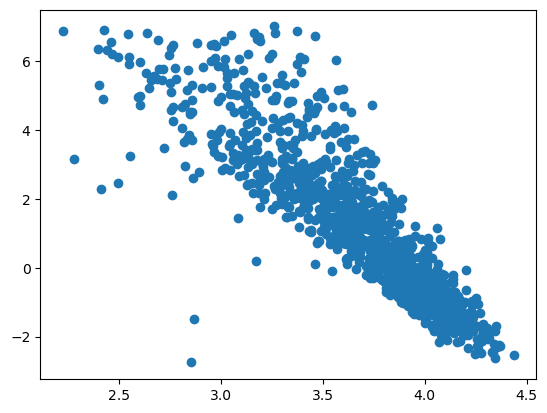

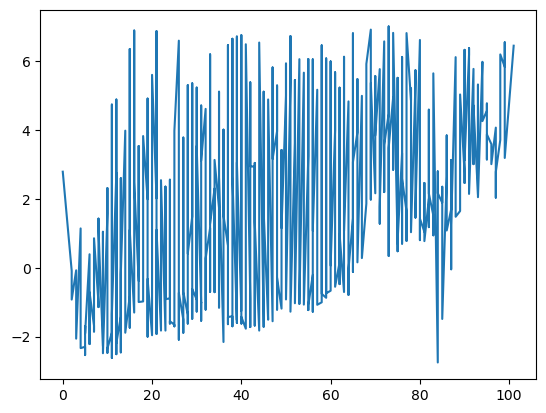

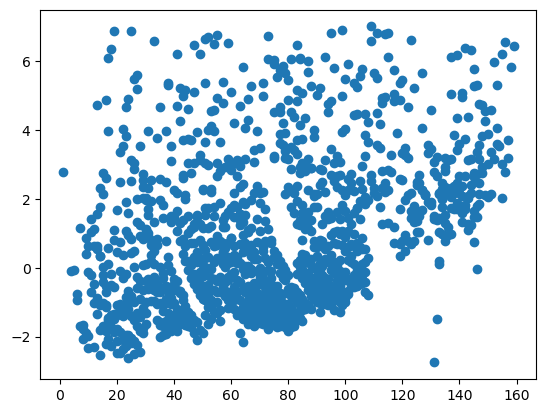

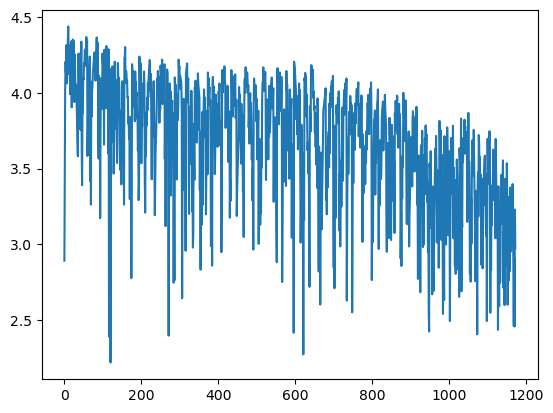

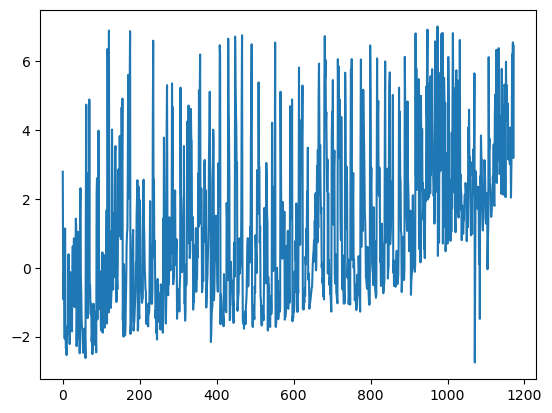

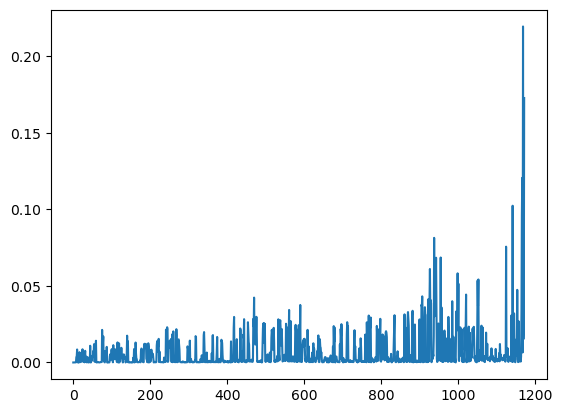

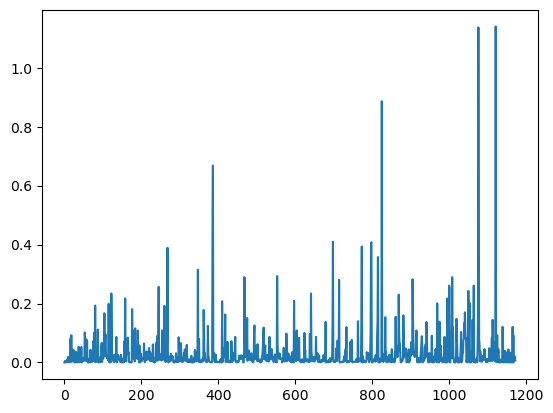

In [53]:
plt.scatter(betaMinusQ,halflife_log_sec)
plt.show()
plt.plot(Np,halflife_log_sec)
plt.show()
plt.scatter(Na-Np,halflife_log_sec)
plt.show()
plt.plot(betaMinusQ)
plt.show()
plt.plot(halflife_log_sec)
plt.show()
plt.plot(betaMinusQUncertainty)
plt.show()
plt.plot(halflife_log_secUncertainty)
plt.show()

随机选择数据编入训练集和测试集

In [54]:
ptrain = 80
pvalid = 10
Ntrain = int(NNuc*ptrain/100)
Nvalidation = int(NNuc*pvalid/100)

train_df = pd.DataFrame({
    "np": Np,
    "nn": Nn,
    "delta": delta,
    "I": I,
    "betaMinusQ": betaMinusQ,
    "betaMinusQUncertainty": betaMinusQUncertainty,
    "halflife_log_sec": halflife_log_sec,
    "halflife_log_sec_uncertainty": halflife_log_secUncertainty,
    "J_i": J_i,
    "parity_i": parity_i,
    "flag_i": flag_i,
    "J_f": J_f,
    "parity_f": parity_f,
    "flag_f": flag_f,
    "delta_J": delta_J,
    "delta_parity": delta_parity,
})

#训练集
train_sample = train_df.sample(n=Ntrain, random_state=randint(114514,1919810))
rest_df = train_df.drop(train_sample.index)
#验证集
valid_sample = rest_df.sample(n=Nvalidation, random_state=randint(114514,1919810))
#测试集
test_sample = rest_df.drop(valid_sample.index)

train_sample.to_csv("train.csv", index=False, encoding="utf-8-sig")
valid_sample.to_csv("validation.csv", index=False, encoding="utf-8-sig")
test_sample.to_csv("test.csv", index=False, encoding="utf-8-sig")